<a href="https://colab.research.google.com/github/tonycuenca99-hue/ARQUIVOS-IA/blob/main/aula_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#importar dados
from google.colab import files
uploaded=files.upload()

Saving iiot_30min_norm.csv to iiot_30min_norm.csv


In [3]:
#ler o arquivo
df=pd.read_csv("iiot_30min_norm.csv")

In [4]:
#selecionar colunas numericas
numeric_cols=df.select_dtypes (include=[np.number]).columns.tolist()

In [6]:
#selecionar colunas numericos para os dados de trinamento
x=df[numeric_cols]
y=df["FM1"]

In [9]:
# VERIFICAR E REMOVER COLUNAS FALTANTES
cols_to_remove = []
for col in x.columns:
  if x[col].isnull().any():  # Corrected: added () to call the isnull method
    print(f"coluna {col} contem valores faltantes")
    cols_to_remove.append(col) # Collect columns to remove

x = x.drop(columns=cols_to_remove) # Drop columns after the loop

In [11]:
#remover target to x
x=x.drop(columns=["FM1"])

In [12]:
#DIVIDIR OS DADOS
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x,y, test_size=0.3, random_state=42)

In [14]:
#treinar
from sklearn.linear_model import LinearRegression
model_val_cruzada=LinearRegression()
model_val_cruzada.fit(x_train, y_train)

LinearRegression()

In [15]:
#fazer predicoes
y_pred=model_val_cruzada.predict(x_test)

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
#calcukar as metricas
mse_val_cruzada=mean_squared_error(y_test, y_pred)
r2_val_cruzada=r2_score(y_test, y_pred)

print (f"r2: {r2_val_cruzada}")
print (f"mse: {mse_val_cruzada}")

r2: -0.23552425798576682
mse: 0.016753012765173197


In [21]:
#utilizar o metrod de k-fold vlidation
n=len(x)
k=10
fold_size=n//k
cv_scores=[]
mse_values=[]
r2_values=[]

In [24]:
for fold in range(k):
    print(f"fold: {fold}")
    start = fold * fold_size
    end = start + fold_size if fold < k - 1 else n
    test_indices_fold= list (range(start, end))
    train_indices_fold=[index for index in range(n) if index not in test_indices_fold]
    #separar dados
    x_train_fold=x.iloc[train_indices_fold]
    y_train_fold=y.iloc[train_indices_fold]
    x_test_fold=x.iloc[test_indices_fold]
    y_test_fold=y.iloc[test_indices_fold]
    #treinar
    model_fold=LinearRegression()
    model_fold.fit(x_train_fold, y_train_fold)
    #fazer predicoes
    y_pred_fold=model_fold.predict(x_test_fold)
    #calcular as metricas
    mse_fold=mean_squared_error(y_test_fold, y_pred_fold)
    r2_fold=r2_score(y_test_fold, y_pred_fold)
    print(f"r2: {r2_fold}")
    print(f"mse: {mse_fold}")
    cv_scores.append(r2_fold)
    mse_values.append(mse_fold)
    r2_values.append(r2_fold)

fold: 0
r2: -164.10811684124764
mse: 0.0165896091252775
fold: 1
r2: -1.1296025272946184
mse: 0.05361129694780883
fold: 2
r2: -1.894317577258187
mse: 0.006488759533184082
fold: 3
r2: -1.3653771490065134
mse: 0.004237508622741577
fold: 4
r2: -0.4312666061215775
mse: 0.024255504342343106
fold: 5
r2: -4.159034890620971
mse: 0.024254117013276046
fold: 6
r2: -0.7270703021814737
mse: 0.0006492766422342536
fold: 7
r2: -10.921993963922208
mse: 0.002262497695053189
fold: 8
r2: -36.34670788939792
mse: 0.005182478206323412
fold: 9
r2: -0.17066056122742856
mse: 0.03266344093915033


In [25]:
#bootstrap
n_bootstraps=100
bootstrap_scores=[]
n_samples=len(x)
r2_score_boot=[]
coefficients_boots=[]

In [27]:
#executar bootstrap
for i in range(n_bootstraps):
    print(f"executando iteracao: {i+1}")
    #amostragem
    bootstrap_indices=np.random.choice(n_samples, size=n_samples, replace=True)
    x_bootstrap=x.iloc[bootstrap_indices]
    y_bootstrap=y.iloc[bootstrap_indices]
    #treinar
    x_bootstrap_train, x_bootstrap_test, y_bootstrap_train, y_bootstrap_test=train_test_split(x_bootstrap, y_bootstrap, test_size=0.3, random_state=42)
    #fazer predicoes
    model_bootstrap=LinearRegression()
    model_bootstrap.fit(x_bootstrap_train, y_bootstrap_train)
    #fazer predicoes
    y_pred_bootstrap=model_bootstrap.predict(x_bootstrap_test)
    #calcular as metricas
    r2_bootstrap=r2_score(y_bootstrap_test, y_pred_bootstrap)
    mse_bootstrap=mean_squared_error(y_bootstrap_test, y_pred_bootstrap)
    print(f"r2: {r2_bootstrap}")
    print(f"mse: {mse_bootstrap}")
    #mostrar metricas de erro
    print(f"erro de treino: {model_bootstrap.score(x_bootstrap_train, y_bootstrap_train)}")
    print(f"erro de teste: {model_bootstrap.score(x_bootstrap_test, y_bootstrap_test)}")
    r2_score_boot.append(r2_bootstrap)
    coefficients_boots.append(model_bootstrap.coef_)

executando iteracao: 1
r2: 0.5152590194265194
mse: 0.007233367740591611
erro de treino: 0.47316605774295295
erro de teste: 0.5152590194265194
executando iteracao: 2
r2: 0.23590524859474793
mse: 0.009046267370184394
erro de treino: 0.2833842793151047
erro de teste: 0.23590524859474793
executando iteracao: 3
r2: 0.5160458014513041
mse: 0.006293526640089958
erro de treino: 0.4977137363080584
erro de teste: 0.5160458014513041
executando iteracao: 4
r2: -0.1990458267257278
mse: 0.01714769847582505
erro de treino: 0.4775537359620746
erro de teste: -0.1990458267257278
executando iteracao: 5
r2: 0.35716594175397864
mse: 0.007842896879377177
erro de treino: 0.34980957206264274
erro de teste: 0.35716594175397864
executando iteracao: 6
r2: 0.1919185359710257
mse: 0.010835544375106362
erro de treino: 0.5008265144033317
erro de teste: 0.1919185359710257
executando iteracao: 7
r2: 0.315697423414494
mse: 0.009057649214813574
erro de treino: 0.3816955513641328
erro de teste: 0.315697423414494
executan

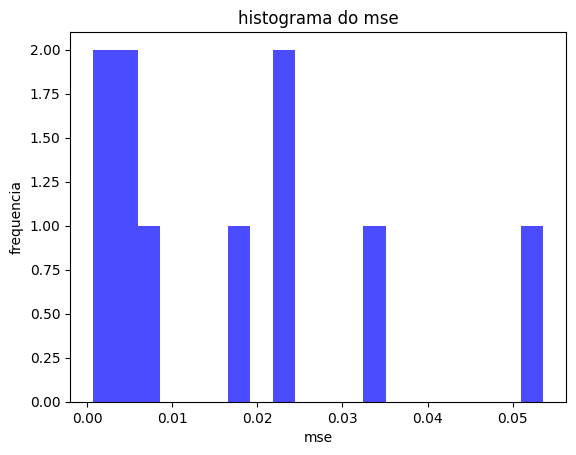

In [30]:
#histograma do mse
plt.hist(mse_values, bins=20, color="blue", alpha=0.7)
plt.xlabel("mse")
plt.ylabel("frequencia")
plt.title("histograma do mse")
plt.show()

In [31]:
#best subset selection
from sklearn.feature_selection import RFE
from sklearn.feature_selection import SequentialFeatureSelector

In [32]:
rfe=RFE(estimator=LinearRegression(), n_features_to_select=5)
rfe.fit(x_train, y_train)

RFE(estimator=LinearRegression(), n_features_to_select=5)

In [33]:
feature_names =x.columns

In [34]:
selected_features=feature_names[rfe.support_]
print("melhores features:")
print(selected_features)
#

melhores features:
Index(['PE1', 'PE2', 'PE3', 'PE4', 'TP2'], dtype='object')


In [35]:
#fazer predicoes
y_pred=rfe.predict(x_test)

In [36]:
#demostrar metricas de erro
mse_rfe=mean_squared_error(y_test, y_pred)
r2_rfe=r2_score(y_test, y_pred)
print(f"r2: {r2_rfe}")
print(f"mse: {mse_rfe}")

r2: -0.07408252343667021
mse: 0.014563953811250275


In [37]:
#forward subset selection
forward_selector=SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction="forward")
forward_selector.fit(x_train, y_train)

SequentialFeatureSelector(estimator=LinearRegression(), n_features_to_select=5)

In [38]:
forward_features=feature_names[forward_selector.get_support()]
print("melhores features:")
print(forward_features)

melhores features:
Index(['PE1', 'PE4', 'TP1', 'TP2', 'EPOCH'], dtype='object')


In [39]:
print (f"features selecionadas: {forward_features}")

features selecionadas: Index(['PE1', 'PE4', 'TP1', 'TP2', 'EPOCH'], dtype='object')


In [40]:
#backward subset selection
backward_selector=SequentialFeatureSelector(LinearRegression(), n_features_to_select=5, direction="backward")
backward_selector.fit(x_train, y_train)

SequentialFeatureSelector(direction='backward', estimator=LinearRegression(),
                          n_features_to_select=5)